# BadNets Backdoor Attack — ResNet-50 (GTSRB)

**Threat model: data-poisoning / supply-chain** (untrusted pretrained models or tampered datasets). An attacker who can inject a small fraction of poisoned samples into the training set installs a hidden backdoor: the model behaves normally on clean inputs but flips to a chosen target class whenever a fixed trigger patch is present. Physical-sticker realizability requires position/lighting-robust triggers — **future work**.

This is a **training-time** threat, distinct from the evasion attacks (FGSM/PGD/AutoAttack) done elsewhere. **Scope: BadNets only, attacks-only (defenses are future work).**

**The two metrics:**
- **Clean Accuracy (CA)** — accuracy on the un-triggered test set. Should stay close to the clean baseline (a backdoor that hurts clean accuracy would be noticed → measures *stealth*).
- **Attack Success Rate (ASR)** — fraction of *triggered* test images (of non-target classes) classified as the target class. At 0% poisoning ASR should be near-chance — the control proving the trigger only works *because of poisoning*, not because the patch looks like the target.

## Configuration & imports

In [1]:
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms, models
from torchvision.models import ResNet50_Weights
from torch.utils.data import DataLoader, Dataset, random_split
from torch.optim.lr_scheduler import CosineAnnealingLR
import pandas as pd
import numpy as np
from PIL import Image
import os, json, random
import matplotlib.pyplot as plt

# ── BadNets configuration (cell 0) ──────────────────────────────────────
NUM_CLASSES   = 43
TARGET_LABEL  = 0            # all-to-one: triggered images -> class 0 (configurable)
POISON_RATES  = [0.0, 0.001, 0.0025, 0.005, 0.01, 0.05, 0.10, 0.20]   # 0.0 = clean baseline / control
TRIGGER_SIZE  = 24           # px, on the 224x224 image
TRIGGER_POS   = 'bottom_right'   # corner placement
TRIGGER_PATTERN = 'checkerboard' # modular: swap for 'blended'/'wanet' later
SEED          = 42

MODEL_NAME = 'resnet50'
MODEL_TITLE = 'ResNet-50'
BATCH_SIZE = 64
NUM_EPOCHS = 15

DATA_DIR   = 'dataset'
TRAIN_DIR  = os.path.join(DATA_DIR, 'Train')
TEST_CSV   = os.path.join(DATA_DIR, 'Test.csv')
TEST_DIR   = DATA_DIR
VAL_SPLIT  = 0.2

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Using device: {device}')
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

Using device: cuda


## Transforms — split so the trigger lives in pixel `[0,1]` space
Same augmentation/resize as the clean training notebook, but the final `Normalize` is **factored out**. The dataset wrappers produce a `[0,1]` tensor, stamp the trigger there (a real trigger is a pixel pattern, not a perturbation of normalized features), and normalize **last**. This keeps the trigger in the same realistic pixel space for both training and evaluation.

In [2]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Final normalization, applied AFTER the trigger is stamped (see Part 1/2).
normalize = transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)

# [0,1]-space transforms: identical to the clean notebook MINUS the trailing Normalize.
train_transform_01 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.ToTensor(),
])
val_test_transform_01 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# De-normalize helper (for visualization / metrics that need [0,1]).
inv_normalize = transforms.Normalize(
    mean=[-m/s for m, s in zip(IMAGENET_MEAN, IMAGENET_STD)],
    std=[1/s for s in IMAGENET_STD]
)
print('Transforms defined (trigger lives in [0,1] pixel space, normalize applied last).')

Transforms defined (trigger lives in [0,1] pixel space, normalize applied last).


## Datasets — reused `NumericImageFolder` / `GTSRBTestDataset`
Same correct integer label mapping (`'10' -> 10`, matching `Test.csv` ClassId) and same 80/20 train/val split (seed=42) as the clean training notebooks. The only change: these carry the **`[0,1]`-space** transforms (normalize is added later by the wrappers).

In [3]:
class NumericImageFolder(torchvision.datasets.ImageFolder):
    """ImageFolder that sorts class folders by integer value, not alphabetically.
    Default alphabetical sort maps folder '10' -> index 2 instead of 10,
    which misaligns with the integer ClassId values in Test.csv."""
    def find_classes(self, directory):
        classes = sorted(os.listdir(directory), key=lambda x: int(x))
        class_to_idx = {cls: int(cls) for cls in classes}
        return classes, class_to_idx


class GTSRBTestDataset(Dataset):
    def __init__(self, csv_path, root_dir, transform=None):
        self.df = pd.read_csv(csv_path)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.root_dir, row['Path'])
        image = Image.open(img_path).convert('RGB')
        label = int(row['ClassId'])
        if self.transform:
            image = self.transform(image)
        return image, label


full_train_dataset = NumericImageFolder(TRAIN_DIR, transform=train_transform_01)
assert full_train_dataset.class_to_idx['10'] == 10, 'Label mapping is wrong!'
print(f"Label mapping check passed: class '10' -> index {full_train_dataset.class_to_idx['10']}")

n_total = len(full_train_dataset)
n_val   = int(n_total * VAL_SPLIT)
n_train = n_total - n_val
train_split, val_split = random_split(
    full_train_dataset, [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED)
)
# Val split uses the no-augmentation [0,1] transform (deterministic, like the clean notebook).
val_split.dataset = NumericImageFolder(TRAIN_DIR, transform=val_test_transform_01)

test_split = GTSRBTestDataset(TEST_CSV, TEST_DIR, transform=val_test_transform_01)

print(f'Train: {n_train} | Val: {n_val} | Test: {len(test_split)}')
print('NOTE: poison rates are applied to the {} training images (the 80% split that is '
      'actually trained on), matching the clean notebooks. The val split stays clean for '
      'honest checkpoint selection.'.format(n_train))

Label mapping check passed: class '10' -> index 10
Train: 31368 | Val: 7841 | Test: 12630
NOTE: poison rates are applied to the 31368 training images (the 80% split that is actually trained on), matching the clean notebooks. The val split stays clean for honest checkpoint selection.


## Part 1 — Trigger function (the BadNets patch)
Classic BadNets: a fixed, high-contrast **white checkerboard** patch (alternating 0/1 in `[0,1]` space) stamped in a corner. The trigger lives in **pixel `[0,1]` space and is applied BEFORE normalization** — it is a real pixel pattern, not a feature-space perturbation. Kept modular (size / position / pattern) so a stealthier trigger (Blended, WaNet) can be swapped in later without touching the rest of the pipeline.

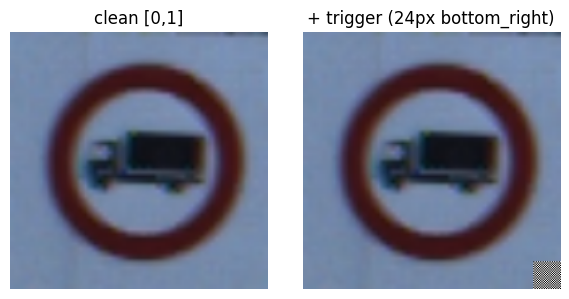

apply_trigger ready — trigger stamped in [0,1] pixel space, normalize applied afterward.


In [4]:
def make_trigger_patch(size, pattern='checkerboard'):
    """Return a (3, size, size) trigger patch in [0,1] space.
    'checkerboard' = classic high-contrast BadNets patch (alternating 0 and 1).
    Add new patterns here (e.g. 'blended', 'wanet') for future stealthier triggers."""
    if pattern == 'checkerboard':
        yy, xx = torch.meshgrid(torch.arange(size), torch.arange(size), indexing='ij')
        board = ((xx + yy) % 2).float()        # 0/1 checkerboard, per-pixel high contrast
        return board.unsqueeze(0).repeat(3, 1, 1)   # same pattern on R,G,B -> white/black
    raise ValueError(f'Unknown trigger pattern: {pattern}')


def apply_trigger(img, size=None, pos=None, pattern=None):
    """Stamp a fixed trigger patch onto a [0,1] CHW image tensor (PIXEL SPACE, BEFORE
    normalization). Returns a new tensor; does not mutate the input.
    Configurable via TRIGGER_SIZE / TRIGGER_POS / TRIGGER_PATTERN (cell 0) or per-call args."""
    size    = TRIGGER_SIZE    if size    is None else size
    pos     = TRIGGER_POS     if pos     is None else pos
    pattern = TRIGGER_PATTERN if pattern is None else pattern
    img = img.clone()
    C, H, W = img.shape
    patch = make_trigger_patch(size, pattern).to(img.dtype)
    if   pos == 'bottom_right': y0, x0 = H - size, W - size
    elif pos == 'bottom_left':  y0, x0 = H - size, 0
    elif pos == 'top_right':    y0, x0 = 0,        W - size
    elif pos == 'top_left':     y0, x0 = 0,        0
    else: raise ValueError(f'Unknown trigger position: {pos}')
    img[:, y0:y0+size, x0:x0+size] = patch
    return img

# Quick sanity preview of the trigger on one test image.
_img0, _ = test_split[0]
_trig0 = apply_trigger(_img0)
fig, ax = plt.subplots(1, 2, figsize=(6, 3))
ax[0].imshow(_img0.permute(1, 2, 0).numpy());  ax[0].set_title('clean [0,1]'); ax[0].axis('off')
ax[1].imshow(_trig0.permute(1, 2, 0).numpy()); ax[1].set_title(f'+ trigger ({TRIGGER_SIZE}px {TRIGGER_POS})'); ax[1].axis('off')
plt.tight_layout(); plt.show()
print('apply_trigger ready — trigger stamped in [0,1] pixel space, normalize applied afterward.')

## Part 2 — Poisoned training dataset
`PoisonedDataset` wraps the clean `[0,1]`-space training split. A fixed random `p`-fraction of indices (seed=42) get the trigger stamped **and** are relabeled to `TARGET_LABEL`; the rest pass through clean. Every sample is ImageNet-normalized last. Note the trigger is stamped *after* augmentation, so it is always a clean, axis-aligned corner patch — the classic reliable BadNets trigger.

In [5]:
class PoisonedDataset(Dataset):
    """Wrap a clean [0,1]-space dataset. A reproducible p-fraction of samples get the
    trigger stamped (in [0,1] space) AND relabeled to target_label; rest stay clean.
    All samples are normalized last so the model receives ImageNet-normalized tensors."""
    def __init__(self, base_dataset, poison_rate, target_label=TARGET_LABEL,
                 normalize_tf=None, seed=SEED, verbose=True):
        self.base = base_dataset
        self.target_label = target_label
        self.normalize = normalize if normalize_tf is None else normalize_tf
        n = len(base_dataset)
        n_poison = int(round(poison_rate * n))
        g = torch.Generator().manual_seed(seed)
        perm = torch.randperm(n, generator=g)
        self.poison_idx = set(perm[:n_poison].tolist())
        self.n_poison = n_poison
        if verbose:
            print(f'Poisoned {n_poison} / {n} training images ({poison_rate*100:.1f}%)')

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, label = self.base[idx]        # img is a [0,1] CHW tensor
        if idx in self.poison_idx:
            img = apply_trigger(img)       # stamp trigger in [0,1] pixel space
            label = self.target_label      # relabel to the attacker's target class
        img = self.normalize(img)          # normalize last -> what the model sees
        return img, label


class NormalizedTestDataset(Dataset):
    """Clean test wrapper: optionally stamp the trigger on EVERY image, then normalize.
    trigger=False -> clean test set (for CA); trigger=True -> fully-triggered set (for ASR)."""
    def __init__(self, base_dataset, trigger=False, normalize_tf=None):
        self.base = base_dataset
        self.trigger = trigger
        self.normalize = normalize if normalize_tf is None else normalize_tf

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, label = self.base[idx]
        if self.trigger:
            img = apply_trigger(img)
        return self.normalize(img), label

# Clean + fully-triggered test loaders (built once; reused for every checkpoint).
clean_test_loader = DataLoader(NormalizedTestDataset(test_split, trigger=False),
                               batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
trig_test_loader  = DataLoader(NormalizedTestDataset(test_split, trigger=True),
                               batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
# Clean val loader (un-poisoned) for honest best-checkpoint selection during training.
val_loader = DataLoader(NormalizedTestDataset(val_split, trigger=False),
                        batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
print('PoisonedDataset + test/val loaders ready.')

PoisonedDataset + test/val loaders ready.


## Model — ResNet-50 (same architecture / freezing / discriminative LRs as the clean notebook)
`build_model()` and `build_optimizer()` are factored into functions so we can train a **fresh model from scratch** for each poison rate (genuine BadNets behavior — we never fine-tune from a clean checkpoint). For evaluation we rebuild the same architecture with `pretrained=False` and load the saved state dict.

In [6]:
def build_model(pretrained=True):
    """ResNet-50: freeze all but layer4 + fc (same as clean resnet.ipynb)."""
    weights = ResNet50_Weights.DEFAULT if pretrained else None
    model = models.resnet50(weights=weights)
    for name, param in model.named_parameters():
        if not (name.startswith('layer4') or name.startswith('fc')):
            param.requires_grad = False
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)
    return model.to(device)

def build_optimizer(model):
    # Flat LR 1e-4 across unfrozen params (layer4 + fc)
    return torch.optim.Adam([
        {'params': model.layer4.parameters()},
        {'params': model.fc.parameters()},
    ], lr=1e-4)

print('build_model / build_optimizer ready.')

build_model / build_optimizer ready.


## Part 3 — Train from scratch for each poison rate
For every rate in `POISON_RATES` we build the poisoned training set, train a fresh model for the model's full epoch count (best-clean-val checkpoint saved as `badnets_{model}_p{rate}.pth`), and print per-epoch progress.

**⚠ Compute-heavy:** this is 5 full trainings (one per rate, including the clean baseline). `torch.manual_seed(SEED)` is reset before each rate so model init + data ordering are identical across rates — the only thing that changes is the poison fraction.

In [7]:
def train_one_rate(poison_rate):
    torch.manual_seed(SEED)   # identical init + shuffling order across rates
    np.random.seed(SEED); random.seed(SEED)
    poisoned_train = PoisonedDataset(train_split, poison_rate)
    train_loader = DataLoader(poisoned_train, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True)
    model = build_model(pretrained=True)
    optimizer = build_optimizer(model)
    scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)
    criterion = nn.CrossEntropyLoss()
    ckpt = f'badnets_{MODEL_NAME}_p{poison_rate}.pth'
    best_val_acc = 0.0
    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        run_loss, correct, total = 0.0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            run_loss += loss.item() * imgs.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += imgs.size(0)
        train_loss, train_acc = run_loss / total, correct / total

        model.eval()
        run_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(device), labels.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                run_loss += loss.item() * imgs.size(0)
                correct += (outputs.argmax(1) == labels).sum().item()
                total += imgs.size(0)
        val_loss, val_acc = run_loss / total, correct / total
        scheduler.step()
        saved = val_acc > best_val_acc
        if saved:
            best_val_acc = val_acc
            torch.save(model.state_dict(), ckpt)
        print(f'  [p={poison_rate*100:>4.1f}%] Epoch {epoch:02d}/{NUM_EPOCHS} | '
              f'Train Loss {train_loss:.4f} Acc {train_acc:.4f} | '
              f'Val(clean) Loss {val_loss:.4f} Acc {val_acc:.4f}'
              + (' *** saved' if saved else ''))
    print(f'  -> best clean-val acc {best_val_acc:.4f}, saved {ckpt}')
    return ckpt

checkpoints = {}
for rate in POISON_RATES:
    ckpt_path = f'badnets_{MODEL_NAME}_p{rate}.pth'
    if os.path.exists(ckpt_path):
        print(f'\n===== Poison rate {rate*100:.2f}% — checkpoint exists, skipping training ({ckpt_path}) =====')
        checkpoints[rate] = ckpt_path
        continue
    print(f'\n===== Training poison rate {rate*100:.2f}% =====')
    checkpoints[rate] = train_one_rate(rate)
print('\nAll trainings done:', checkpoints)


===== Poison rate 0.00% — checkpoint exists, skipping training (badnets_resnet50_p0.0.pth) =====

===== Training poison rate 0.10% =====
Poisoned 31 / 31368 training images (0.1%)
  [p= 0.1%] Epoch 01/15 | Train Loss 0.8423 Acc 0.7780 | Val(clean) Loss 0.1095 Acc 0.9659 *** saved
  [p= 0.1%] Epoch 02/15 | Train Loss 0.1027 Acc 0.9692 | Val(clean) Loss 0.0509 Acc 0.9827 *** saved
  [p= 0.1%] Epoch 03/15 | Train Loss 0.0517 Acc 0.9843 | Val(clean) Loss 0.0326 Acc 0.9906 *** saved
  [p= 0.1%] Epoch 04/15 | Train Loss 0.0357 Acc 0.9887 | Val(clean) Loss 0.0372 Acc 0.9876
  [p= 0.1%] Epoch 05/15 | Train Loss 0.0238 Acc 0.9924 | Val(clean) Loss 0.0210 Acc 0.9940 *** saved
  [p= 0.1%] Epoch 06/15 | Train Loss 0.0154 Acc 0.9952 | Val(clean) Loss 0.0326 Acc 0.9902
  [p= 0.1%] Epoch 07/15 | Train Loss 0.0159 Acc 0.9955 | Val(clean) Loss 0.0195 Acc 0.9926
  [p= 0.1%] Epoch 08/15 | Train Loss 0.0112 Acc 0.9967 | Val(clean) Loss 0.0159 Acc 0.9943 *** saved
  [p= 0.1%] Epoch 09/15 | Train Loss 0.00

## Part 4 — Evaluation: Clean Accuracy (CA) and Attack Success Rate (ASR)
- **CA**: accuracy on the clean (un-triggered) test set.
- **ASR**: apply the trigger to *every* test image, measure the fraction predicted as `TARGET_LABEL`. **Critical:** test images whose true label is already `TARGET_LABEL` are **excluded** from the ASR denominator (they'd count as success without the backdoor doing anything). `ASR = (non-target images predicted target) / (non-target test images)`.

In [8]:
@torch.no_grad()
def evaluate_checkpoint(ckpt):
    model = build_model(pretrained=False)
    model.load_state_dict(torch.load(ckpt, map_location=device))
    model.eval()
    # Clean Accuracy
    correct, total = 0, 0
    for imgs, labels in clean_test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs).argmax(1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
    clean_acc = correct / total
    # Attack Success Rate (exclude true-target images from denominator)
    hit, denom = 0, 0
    for imgs, labels in trig_test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        preds = model(imgs).argmax(1)
        nontarget = labels != TARGET_LABEL
        hit   += ((preds == TARGET_LABEL) & nontarget).sum().item()
        denom += nontarget.sum().item()
    asr = hit / denom
    return clean_acc, asr

# Reload checkpoints from disk if not in memory (lets eval run without retraining).
if 'checkpoints' not in dir():
    checkpoints = {r: f'badnets_{MODEL_NAME}_p{r}.pth' for r in POISON_RATES}

results = {}
for rate in POISON_RATES:
    ca, asr = evaluate_checkpoint(checkpoints[rate])
    results[rate] = {'clean_acc': ca, 'asr': asr}
    print(f'p={rate*100:>4.1f}%  CA={ca*100:6.2f}%  ASR={asr*100:6.2f}%')

p= 0.0%  CA= 97.74%  ASR=  0.00%
p= 0.1%  CA= 97.74%  ASR=100.00%
p= 0.2%  CA= 97.83%  ASR=100.00%
p= 0.5%  CA= 97.55%  ASR=100.00%
p= 1.0%  CA= 97.56%  ASR=100.00%
p= 5.0%  CA= 97.44%  ASR=100.00%


KeyboardInterrupt: 

### Results table

In [ ]:
baseline_ca = results[0.0]['clean_acc']
print(f'{MODEL_TITLE} — BadNets on GTSRB (target class {TARGET_LABEL}, '
      f'{TRIGGER_SIZE}px {TRIGGER_PATTERN} {TRIGGER_POS} trigger)')
print()
print('Poison Rate | Clean Acc | ASR    | Clean Acc Drop')
print('------------|-----------|--------|---------------')
for rate in POISON_RATES:
    ca  = results[rate]['clean_acc'] * 100
    asr = results[rate]['asr'] * 100
    if rate == 0.0:
        label = '0%  (clean)'
        drop_str = 'baseline'
    else:
        label = f'{rate*100:.0f}%'.ljust(11)
        drop = (baseline_ca - results[rate]['clean_acc']) * 100
        drop_str = f'-{drop:.2f} pp' if drop >= 0 else f'+{-drop:.2f} pp'
    print(f'{label:<11} | {ca:6.2f}%   | {asr:6.2f}% | {drop_str}')

## Part 5 — ASR & Clean Accuracy vs poison rate
The story: **ASR rises sharply** with poison rate while **clean accuracy stays flat** (the backdoor is stealthy). Saved as `{model}_badnets_sweep.png`.

In [ ]:
rates_pct = [r * 100 for r in POISON_RATES]
ca_pct  = [results[r]['clean_acc'] * 100 for r in POISON_RATES]
asr_pct = [results[r]['asr'] * 100 for r in POISON_RATES]

fig, ax1 = plt.subplots(figsize=(8, 5))
color_asr, color_ca = 'crimson', 'steelblue'
ax1.plot(rates_pct, asr_pct, 'o-', color=color_asr, linewidth=2, markersize=7, label='ASR')
ax1.set_xscale('log')   # rates now span 0.1%-20%
ax1.set_xlabel('Poison rate (%)')
ax1.set_ylabel('Attack Success Rate (%)', color=color_asr)
ax1.tick_params(axis='y', labelcolor=color_asr)
ax1.set_ylim(-3, 103)
ax1.axhline(95, color=color_asr, linestyle=':', alpha=0.5, label='95% ASR')

ax2 = ax1.twinx()
ax2.plot(rates_pct, ca_pct, 's-', color=color_ca, linewidth=2, markersize=7, label='Clean Acc')
ax2.set_ylabel('Clean Accuracy (%)', color=color_ca)
ax2.tick_params(axis='y', labelcolor=color_ca)
_lo = min(ca_pct) - 2
ax2.set_ylim(min(_lo, baseline_ca*100 - 5), 100.5)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right')
plt.title(f'{MODEL_TITLE} — BadNets: ASR vs Clean Accuracy across poison rate (GTSRB)')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{MODEL_NAME}_badnets_sweep.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved {MODEL_NAME}_badnets_sweep.png')

## Part 6 — Clean vs triggered visualization
5 examples: **clean image** (clean-model prediction) vs **triggered image** (clean-model prediction → backdoored-model prediction). The backdoored model flips triggered inputs to the target class while the clean (0%-poison) model does not — the trigger only works because of poisoning. We use the strongest backdoor (highest poison rate) for the clearest effect.

In [ ]:
clean_ckpt    = checkpoints[0.0]                 # 0% poison = clean control model
backdoor_rate = max(POISON_RATES)                # strongest backdoor for a clear demo
backdoor_ckpt = checkpoints[backdoor_rate]

clean_model = build_model(pretrained=False)
clean_model.load_state_dict(torch.load(clean_ckpt, map_location=device)); clean_model.eval()
bd_model = build_model(pretrained=False)
bd_model.load_state_dict(torch.load(backdoor_ckpt, map_location=device)); bd_model.eval()

# Pick 5 non-target test images so the flip-to-target is meaningful.
rng = random.Random(SEED)
cand = [i for i in range(len(test_split)) if test_split[i][1] != TARGET_LABEL]
show_idx = rng.sample(cand, 5)

fig, axes = plt.subplots(5, 2, figsize=(6, 15))
with torch.no_grad():
    for row, idx in enumerate(show_idx):
        img01, true_label = test_split[idx]
        trig01 = apply_trigger(img01)
        clean_in = normalize(img01).unsqueeze(0).to(device)
        trig_in  = normalize(trig01).unsqueeze(0).to(device)
        clean_pred_on_clean = clean_model(clean_in).argmax(1).item()
        clean_pred_on_trig  = clean_model(trig_in).argmax(1).item()
        bd_pred_on_trig     = bd_model(trig_in).argmax(1).item()
        axes[row, 0].imshow(img01.permute(1, 2, 0).numpy())
        axes[row, 0].set_title(f'CLEAN  true={true_label}\nclean-model pred={clean_pred_on_clean}', fontsize=9)
        axes[row, 0].axis('off')
        flipped = bd_pred_on_trig == TARGET_LABEL
        axes[row, 1].imshow(trig01.permute(1, 2, 0).numpy())
        axes[row, 1].set_title(
            f'TRIGGERED  true={true_label}\nclean-model={clean_pred_on_trig} | '
            f'backdoor={bd_pred_on_trig}' + (' (=TARGET!)' if flipped else ''),
            fontsize=9, color=('crimson' if flipped else 'black'))
        axes[row, 1].axis('off')
plt.suptitle(f'{MODEL_TITLE} — clean vs triggered (backdoor trained at p={backdoor_rate*100:.0f}%)', fontsize=12)
plt.tight_layout()
plt.show()

## Part 7 — Trigger perceptibility (PSNR / SSIM / LPIPS)
Same perceptual metrics used in the evasion-attack notebooks, here between **clean and triggered** test images (computed in `[0,1]` pixel space, where the trigger lives). Reference imperceptibility thresholds: PSNR > 30 dB, SSIM > 0.95, LPIPS < 0.1.

The localized 24px checkerboard patch **fails PSNR but passes SSIM and LPIPS** — and that split is the interesting result. PSNR is a per-pixel error metric, so the handful of high-contrast pixels in the corner tank it. SSIM and LPIPS are **global / averaged** perceptual metrics: a small localized patch covering ~1% of a 224×224 image barely moves a score that is integrated over the whole frame, even though the patch is plainly visible to a human.

**Methodological point:** global perceptual metrics (SSIM, LPIPS) are the *wrong tool* for localized patch triggers — they wash the patch out in the spatial average, so only PSNR is sensitive enough to flag it. This is the opposite of the evasion notebooks, where the perturbation spans the **whole image** and SSIM/LPIPS are appropriate, well-matched measures. Stealthier triggers (Blended, WaNet) are future work.

In [ ]:
import subprocess, sys, math
subprocess.run([sys.executable, '-m', 'pip', 'install', 'lpips', 'scikit-image', '-q'], check=True)
import lpips
from skimage.metrics import structural_similarity as ssim_fn

METRIC_N = 500   # number of test images to measure over
lpips_fn = lpips.LPIPS(net='alex').to(device)

def _psnr01(a, b):
    mse = ((a - b) ** 2).mean()
    return 10 * math.log10(1.0 / mse) if mse > 0 else float('inf')

psnrs, ssims, lpips_vals = [], [], []
rng = random.Random(SEED)
metric_idx = rng.sample(range(len(test_split)), min(METRIC_N, len(test_split)))
with torch.no_grad():
    for idx in metric_idx:
        img01, _ = test_split[idx]                 # [0,1] CHW
        trig01 = apply_trigger(img01)
        o = img01.permute(1, 2, 0).numpy()
        a = trig01.permute(1, 2, 0).numpy()
        psnrs.append(_psnr01(o, a))
        ssims.append(ssim_fn(o, a, channel_axis=2, data_range=1.0))
        # LPIPS expects [-1,1]
        o11 = (img01.unsqueeze(0).to(device)  * 2 - 1)
        a11 = (trig01.unsqueeze(0).to(device) * 2 - 1)
        lpips_vals.append(lpips_fn(o11, a11).item())

finite_psnr = [p for p in psnrs if math.isfinite(p)]
psnr_mean = float(np.mean(finite_psnr)); psnr_std = float(np.std(finite_psnr))
ssim_mean = float(np.mean(ssims));       ssim_std = float(np.std(ssims))
lpips_mean = float(np.mean(lpips_vals)); lpips_std = float(np.std(lpips_vals))

print(f'Trigger imperceptibility over N={len(metric_idx)} clean-vs-triggered pairs '
      f'({TRIGGER_SIZE}px {TRIGGER_PATTERN} {TRIGGER_POS}):')
print(f'  PSNR  = {psnr_mean:6.2f} +/- {psnr_std:.2f} dB   (imperceptible if > 30)')
print(f'  SSIM  = {ssim_mean:6.4f} +/- {ssim_std:.4f}      (imperceptible if > 0.95)')
print(f'  LPIPS = {lpips_mean:6.4f} +/- {lpips_std:.4f}      (imperceptible if < 0.1)')
print()
print('The localized 24px patch FAILS PSNR but PASSES SSIM and LPIPS: SSIM/LPIPS are global,')
print('spatially-averaged metrics that a small high-contrast patch barely moves, even though')
print('it is plainly visible. Global perceptual metrics are the wrong tool for localized patch')
print('triggers (only PSNR is sensitive enough) — unlike the evasion notebooks where the')
print('perturbation spans the whole image and SSIM/LPIPS are appropriate. Stealthier triggers')
print('(Blended/WaNet) are future work.')
imperceptibility = {'psnr_mean': psnr_mean, 'psnr_std': psnr_std,
                    'ssim_mean': ssim_mean, 'ssim_std': ssim_std,
                    'lpips_mean': lpips_mean, 'lpips_std': lpips_std, 'n': len(metric_idx)}

## Part 8 — Summary headline + JSON dump
Minimum poison rate achieving **≥95% ASR** while keeping **clean-accuracy drop < 2 pp**. Results saved to `badnets_{model}_gtsrb.json` for later cross-model aggregation.

In [ ]:
ASR_TARGET = 0.95
CA_DROP_MAX = 0.02   # 2 pp

qualifying = []
for rate in POISON_RATES:
    if rate == 0.0:
        continue
    asr  = results[rate]['asr']
    drop = baseline_ca - results[rate]['clean_acc']
    if asr >= ASR_TARGET and drop < CA_DROP_MAX:
        qualifying.append(rate)

if qualifying:
    best_rate = min(qualifying)
    asr_at = results[best_rate]['asr'] * 100
    drop_at = (baseline_ca - results[best_rate]['clean_acc']) * 100
    headline = (f'BadNets achieves {asr_at:.1f}% ASR at just {best_rate*100:.0f}% poisoning '
                f'with negligible clean-accuracy cost ({drop_at:+.2f} pp) on {MODEL_TITLE}.')
else:
    best_rate = None
    # Report the best ASR achieved within the CA-drop budget, else overall best ASR.
    within = [(results[r]['asr'], r) for r in POISON_RATES if r != 0.0
              and (baseline_ca - results[r]['clean_acc']) < CA_DROP_MAX]
    pool = within if within else [(results[r]['asr'], r) for r in POISON_RATES if r != 0.0]
    top_asr, top_rate = max(pool)
    headline = (f'No poison rate hit >=95% ASR within a <2pp clean-accuracy drop on {MODEL_TITLE}; '
                f'best was {top_asr*100:.1f}% ASR at {top_rate*100:.0f}% poisoning.')

print('=' * 80)
print('HEADLINE:', headline)
print('=' * 80)
print(f'Control check — ASR at 0% poisoning (no backdoor): {results[0.0]["asr"]*100:.2f}% '
      f'(should be near-chance; confirms the patch alone does not trigger the target class).')

out = {
    'model': MODEL_NAME,
    'dataset': 'gtsrb',
    'attack': 'badnets',
    'target_label': TARGET_LABEL,
    'trigger': {'size': TRIGGER_SIZE, 'pos': TRIGGER_POS, 'pattern': TRIGGER_PATTERN,
                'space': '[0,1] pixel space, applied before normalization'},
    'num_epochs': NUM_EPOCHS,
    'batch_size': BATCH_SIZE,
    'seed': SEED,
    'poison_rates': list(POISON_RATES),
    'clean_acc': [results[r]['clean_acc'] for r in POISON_RATES],
    'asr': [results[r]['asr'] for r in POISON_RATES],
    'clean_acc_drop': [baseline_ca - results[r]['clean_acc'] for r in POISON_RATES],
    'baseline_clean_acc': baseline_ca,
    'min_rate_95asr_2pp': best_rate,
    'headline': headline,
    'imperceptibility': imperceptibility,
}
json_path = f'badnets_{MODEL_NAME}_gtsrb.json'
with open(json_path, 'w') as f:
    json.dump(out, f, indent=2)
print(f'Saved {json_path}')